C:\Users\Raghunandan\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 285ms/step - loss: 0.4160 - val_loss: 0.1380
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2189 - val_loss: 0.0913
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1274 - val_loss: 0.0099
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1127 - val_loss: 0.0938
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0705 - val_loss: 0.0068
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0414 - val_loss: 0.0172
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0647 - val_loss: 0.0054
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0503 - val_loss: 0.0113
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0464 - val_loss: 0.0339
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0602 - val_loss: 0.0162
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0410 - val_loss: 0.0264
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0418 - val_loss: 0.0048


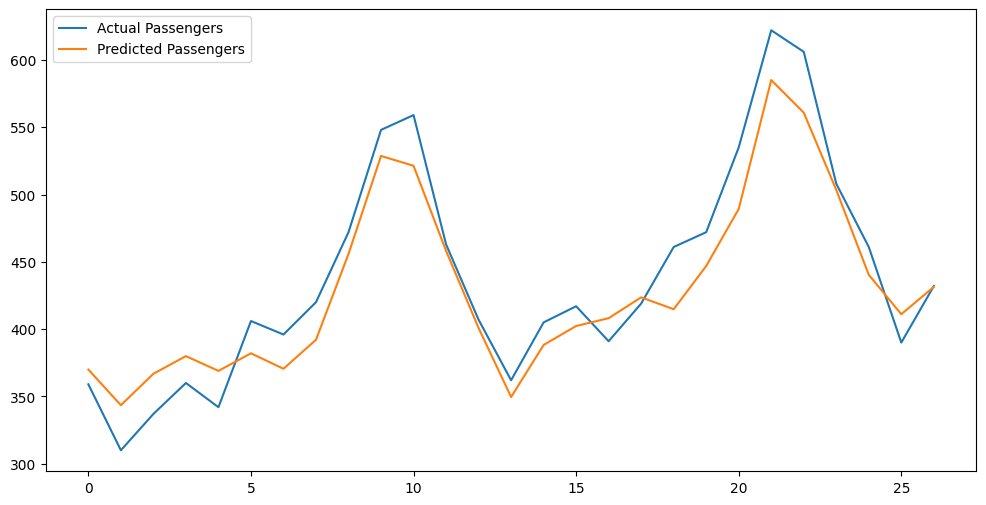


Next 7 Months Passenger Forecast
Month 1: 467
Month 2: 438
Month 3: 448
Month 4: 468
Month 5: 478
Month 6: 534
Month 7: 633


['airpassenger_scaler.pkl']

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense,Dropout,Bidirectional
import matplotlib.pyplot as plt

df=pd.read_csv("AirPassengers.csv")

data=df[['#Passengers']]

scaler=MinMaxScaler(feature_range=(0,1))

scaled_data=scaler.fit_transform(data)

X=[]
y=[]

for i in range(12,len(scaled_data)):
    X.append(scaled_data[i-12:i,0])
    y.append(scaled_data[i,0])

X=np.array(X)
y=np.array(y)

X=X.reshape(X.shape[0],X.shape[1],1)

split=int(len(X)*0.8)

X_train=X[:split]
X_test=X[split:]
y_train=y[:split]
y_test=y[split:]

model=Sequential([
    Bidirectional(SimpleRNN(64,return_sequences=True),input_shape=(12,1)),
    Dropout(0.2),
    Bidirectional(SimpleRNN(32)),
    Dropout(0.2),
    Dense(16),
    Dense(1)
])

model.compile(optimizer='adam',loss='mean_squared_error')

history=model.fit(X_train,y_train,epochs=50,batch_size=16,validation_split=0.2)

predictions=model.predict(X_test)

predictions=scaler.inverse_transform(predictions)

actual=scaler.inverse_transform(y_test.reshape(-1,1))

mae=mean_absolute_error(actual,predictions)
mse=mean_squared_error(actual,predictions)
rmse=np.sqrt(mse)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)

plt.figure(figsize=(12,6))
plt.plot(actual,label="Actual Passengers")
plt.plot(predictions,label="Predicted Passengers")
plt.legend()
plt.show()

last_12_months=scaled_data[-12:].flatten().tolist()

future_passengers=[]

for _ in range(7):
    x=np.array(last_12_months[-12:]).reshape(1,12,1)
    pred=model.predict(x,verbose=0)[0][0]
    future_passengers.append(pred)
    last_12_months.append(pred)

future_passengers=scaler.inverse_transform(np.array(future_passengers).reshape(-1,1))

print("\nNext 7 Months Passenger Forecast")

for i,val in enumerate(future_passengers,start=1):
    print(f"Month {i}: {int(val[0])}")

model.save("airpassenger_birnn.keras")

joblib.dump(scaler,"airpassenger_scaler.pkl")